PS0: Using GIS to Explore a Proposed NJYASA Structure
David Dunkerson

Section 1 — Background and Research Interest

Community youth football is generally organized through local programs that serve individual towns or communities. These organizations may participate in different leagues, and those leagues can have their own rules, registration processes, schedules, training requirements, and administrative systems. Unlike high school or college athletics, there is not one common statewide structure connecting all community youth football organizations in New Jersey.
TYASA is a youth sports organization I am developing with the broader goal of creating more structure, support, and consistency within community youth sports while allowing local organizations to remain independent. The idea is not for TYASA to take over individual youth programs. Instead, it would provide a larger system around them that could help create clearer processes, common standards, education and training resources, competition structures, and administrative support.
NJYASA is the proposed New Jersey state-level part of that larger TYASA model. My preliminary NJYASA concept divides New Jersey into three geographic regions—North, Central, and South. Each of New Jersey's 21 counties would serve as a county conference, and counties with larger numbers of participating organizations could be divided further into smaller geographic divisions. For example, Burlington County would be one conference within the proposed South Region.
My long-term goal for this GIS project is to determine whether this proposed structure makes geographic sense rather than relying only on the structure I originally created. I would eventually like to use the locations of youth football organizations, team participation, youth population, travel distance, and other geographic information to evaluate the proposed regions, conferences, and divisions. Burlington County is especially important because it is also the area where I plan to begin testing the TYASA model on a smaller scale.


Section 2 — Research Question, Unit of Analysis, and Data

Research Question:
How can the geographic distribution of community youth football organizations in New Jersey help evaluate and inform the proposed NJYASA regional and county-conference structure?

Unit of Analysis:
The initial unit of analysis will be New Jersey's 21 counties.

Geographic Scope:
The primary study area is the State of New Jersey. Burlington County will also serve as a more detailed area of focus because it is part of the proposed South Region and is the intended location for an early TYASA county-level pilot.

Data and Variables:
For the first stage of the project, I will use GIS boundary data for New Jersey's 21 counties. This will allow me to create a basic map of the proposed NJYASA regional structure. As the project develops, I plan to incorporate updated data on youth football organizations and their locations, the number of participating teams, youth population, population density, and travel distance. Additional community or demographic variables may also be considered if they help evaluate whether the proposed regions, conferences, and divisions are geographically practical.

Section 3 — GIS Data Source

For the initial map, I will use the County Boundaries of New Jersey dataset provided by the New Jersey Geographic Information Network (NJGIN) and the New Jersey Office of Information Technology, Office of GIS. This dataset contains the geographic boundaries for New Jersey's 21 counties and will provide the base geography for the proposed NJYASA regional and county-conference structure.

I selected this dataset because counties are the initial unit of analysis for the project, with each county representing a proposed NJYASA conference. The county boundaries will allow me to establish the statewide geographic framework before adding youth football organization locations and other variables later in the project.

Dataset: County Boundaries of NJ, Hosted, 3424

Source: New Jersey Geographic Information Network / NJ Office of Information Technology, Office of GIS

Data type: Polygon GIS data / hosted feature layer

Geographic coverage: State of New Jersey — 21 counties

Exact dataset source: https://www.arcgis.com/home/item.html?id=86d33b1f539843268de673825ebd47ec&utm=#overview

Section 4 — Load the GIS Data and Create the First Map

In [1]:
import geopandas as gpd

In [2]:
url = (
    "https://services2.arcgis.com/XVOqAjTOJ5P6ngMu/"
    "arcgis/rest/services/NJ_Counties_3424/FeatureServer/0/query"
    "?where=1%3D1&outFields=*&f=geojson"
)

In [3]:
nj_counties = gpd.read_file(url)

In [4]:
nj_counties.head()

,OBJECTID,COUNTY,COUNTY_LABEL,CO,GNIS_NAME,GNIS,FIPSSTCO,FIPSCO,ACRES,SQ_MILES,...,POP1980,POPDEN2020,POPDEN2010,POPDEN2000,POPDEN1990,POPDEN1980,REGION,Shape__Area,Shape__Length,geometry
0,1,ATLANTIC,Atlantic County,ATL,County of Atlantic,882270,34001,1,390813.840968,610.646627,...,204615,450,450,414,451,335,COASTAL,1.702385e+10,650227.988137,"POLYGON ((-74.67437 39.68858, -74.67433 39.688..."
1,2,BERGEN,Bergen County,BER,County of Bergen,882271,34003,3,153491.054911,239.829773,...,849843,3985,3774,3686,3459,3544,NORTHEASTERN,6.686070e+09,443716.118141,"POLYGON ((-73.90569 40.98315, -73.90591 40.982..."
2,3,BURLINGTON,Burlington County,BUR,County of Burlington,882272,34005,5,524901.239967,820.158187,...,362542,563,547,516,482,442,SOUTHERN,2.286470e+10,788704.755123,"POLYGON ((-74.69864 40.18226, -74.69838 40.182..."
3,4,CAMDEN,Camden County,CAM,County of Camden,882273,34007,7,145594.972008,227.492144,...,471650,2301,2258,2237,2341,2073,SOUTHERN,6.342117e+09,495428.788831,"POLYGON ((-75.03314 39.99483, -75.03299 39.994..."
4,5,CAPE MAY,Cape May County,CAP,County of Cape May,882274,34009,9,183125.841721,286.134128,...,82266,333,340,358,332,288,COASTAL,7.976962e+09,514564.703916,"POLYGON ((-74.85962 39.31897, -74.85955 39.318..."


In [5]:
len(nj_counties)

21

<Axes: >

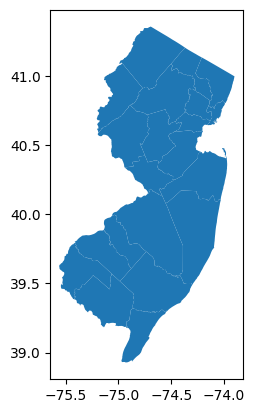

In [6]:
nj_counties.plot()

(np.float64(-75.64242383910356),
 np.float64(-73.81959467270454),
 np.float64(38.807065509412695),
 np.float64(41.47911153221721))

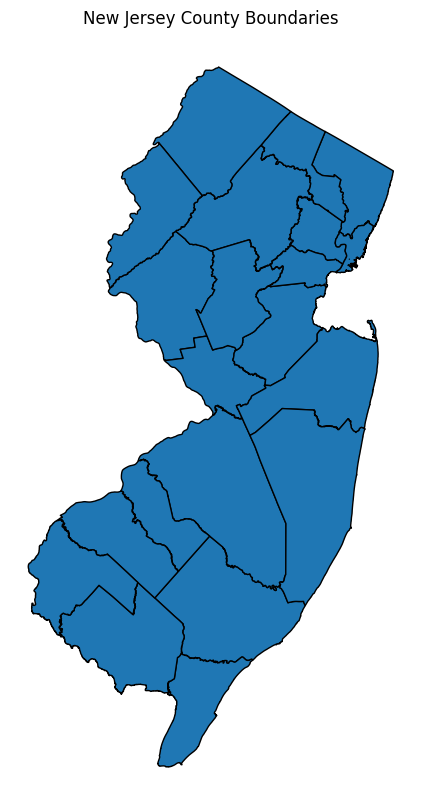

In [7]:
ax = nj_counties.plot(
    edgecolor="black",
    figsize=(8, 10)
)

ax.set_title("New Jersey County Boundaries")
ax.axis("off")

In [8]:
region_lookup = {
    "BERGEN": "North",
    "MORRIS": "North",
    "ESSEX": "North",
    "PASSAIC": "North",
    "SUSSEX": "North",
    "HUDSON": "North",
    "WARREN": "North",

    "MIDDLESEX": "Central",
    "UNION": "Central",
    "MONMOUTH": "Central",
    "SOMERSET": "Central",
    "OCEAN": "Central",
    "MERCER": "Central",
    "HUNTERDON": "Central",

    "CAMDEN": "South",
    "BURLINGTON": "South",
    "ATLANTIC": "South",
    "GLOUCESTER": "South",
    "CAPE MAY": "South",
    "CUMBERLAND": "South",
    "SALEM": "South"
}

In [9]:
nj_counties["NJYASA_REGION"] = nj_counties["COUNTY"].map(region_lookup)

In [10]:
nj_counties[["COUNTY", "NJYASA_REGION"]]

,COUNTY,NJYASA_REGION
0,ATLANTIC,South
1,BERGEN,North
2,BURLINGTON,South
3,CAMDEN,South
4,CAPE MAY,South
5,CUMBERLAND,South
6,ESSEX,North
7,GLOUCESTER,South
8,HUDSON,North
9,HUNTERDON,Central


In [11]:
nj_counties["NJYASA_REGION"].value_counts()

,count
NJYASA_REGION,
South,7
North,7
Central,7


<Axes: >

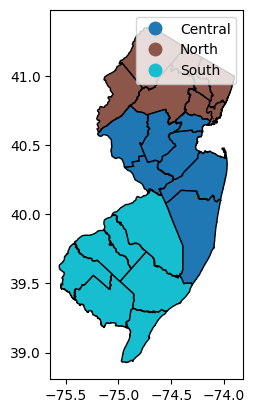

In [12]:
nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black"
)

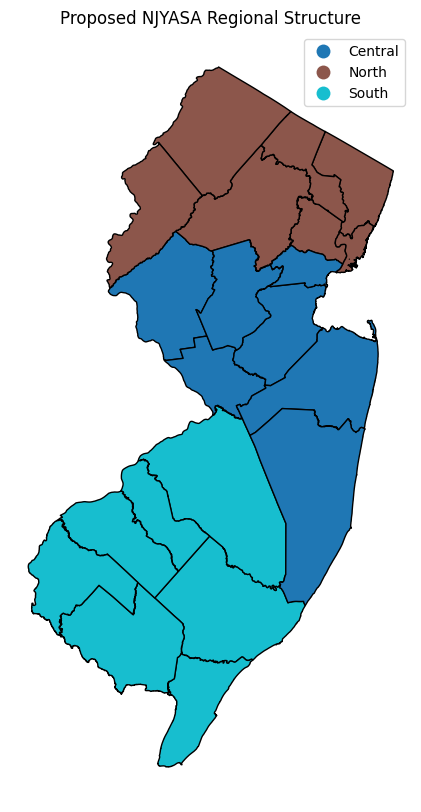

In [13]:
ax = nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black",
    figsize=(8, 10)
)

ax.set_title("Proposed NJYASA Regional Structure")
ax.axis("off");

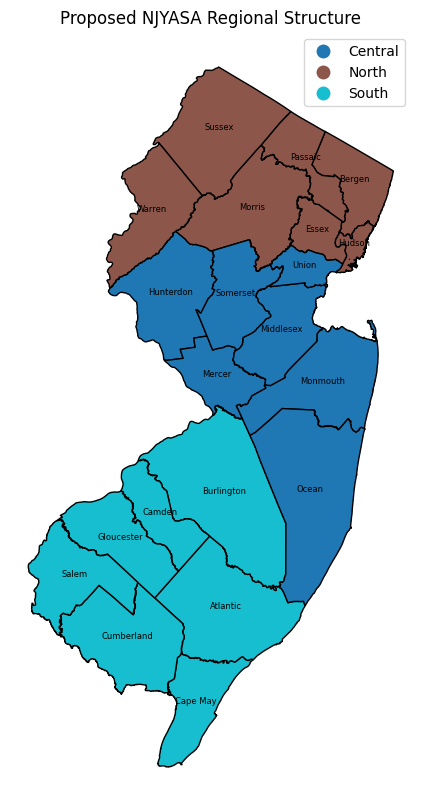

In [14]:
ax = nj_counties.plot(
    column="NJYASA_REGION",
    categorical=True,
    legend=True,
    edgecolor="black",
    figsize=(8, 10)
)

for idx, row in nj_counties.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    ax.text(
        x,
        y,
        row["COUNTY"].title(),
        fontsize=6,
        ha="center"
    )

ax.set_title("Proposed NJYASA Regional Structure")
ax.axis("off");

Section 5 - Initial Map Interpretation

The map shows the preliminary three-region structure I developed for NJYASA. New Jersey's 21 counties are divided into proposed North, Central, and South regions, with seven counties in each region. Under the proposed structure, each county would function as a county conference, while larger conferences could eventually be divided into smaller geographic divisions.

Burlington County is included in the proposed South Region and will also serve as an initial area of focus for TYASA's county-level development. At this stage, the regional assignments represent a preliminary planning model rather than a final structure. Future analysis will use updated youth football organization locations, team distribution, youth population, and travel-related data to evaluate whether these regional boundaries are geographically practical or whether changes should be considered.

Portions of the Python code used in this notebook were developed with assistance from OpenAI ChatGPT and adapted to the NJYASA research project. The workflow also follows concepts demonstrated in the course materials.